--2025-10-15 22:36:13--  https://i.pinimg.com/736x/96/b8/0c/96b80cbd33125c0896d58b24b4616166.jpg
Resolving i.pinimg.com (i.pinimg.com)... 2.18.67.78, 2.18.67.85, 2.18.67.86, ...
Connecting to i.pinimg.com (i.pinimg.com)|2.18.67.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55421 (54K) [image/jpeg]
Saving to: ‘formas.png’

formas.png          100%[===================>]  54.12K  --.-KB/s    in 0s      

2025-10-15 22:36:13 (258 MB/s) - ‘formas.png’ saved [55421/55421]


Librerías instaladas e imagen de ejemplo descargada.
--------------------------------------------------
Paso 1: Imagen original cargada.
Paso 2: Segmentación con umbral FIJO completada.
Paso 3: Segmentación con umbral ADAPTATIVO completada.
--------------------------------------------------
ANÁLISIS DE FORMAS (Se encontraron 272 contornos)
--------------------------------------------------
Paso 4: Análisis de formas y dibujo de resultados completado.
-----------------------------------------

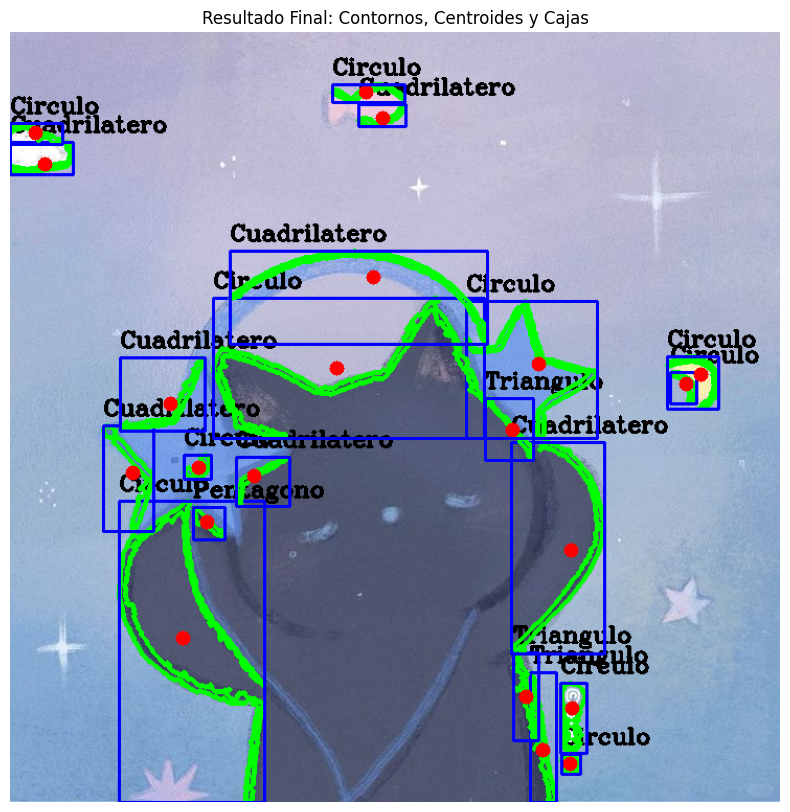

In [ ]:
# ==============================================================================
# 1. INSTALACIÓN Y PREPARACIÓN
# ==============================================================================
!pip install -q opencv-python matplotlib numpy imageio imageio-ffmpeg
!wget -O formas.png https://i.pinimg.com/736x/96/b8/0c/96b80cbd33125c0896d58b24b4616166.jpg

print("\nLibrerías instaladas e imagen de ejemplo descargada.")
print("-" * 50)

# ==============================================================================
# 2. SCRIPT COMPLETO (CON UMBRAL FIJO Y ADAPTATIVO)
# ==============================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os

# --- Paso A: Cargar y preprocesar la imagen ---
image_path = 'formas.png'
if not os.path.exists(image_path):
    print(f"Error: No se encontró la imagen '{image_path}'.")
else:
    original = cv2.imread(image_path)
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (7, 7), 0)

    # Guardar imagen para el GIF
    cv2.imwrite('paso1_original.png', original)
    print("Paso 1: Imagen original cargada.")

    # --- TAREA: UMBRALIZACIÓN FIJA (threshold) ---
    # Se aplica un único umbral (127) a toda la imagen.
    # Los píxeles por debajo de 127 se vuelven negros, los de arriba, blancos.
    _, thresh_fijo = cv2.threshold(gray_blur, 127, 255, cv2.THRESH_BINARY_INV)

    cv2.imwrite('paso2_fijo.png', thresh_fijo)
    print("Paso 2: Segmentación con umbral FIJO completada.")

    # --- TAREA: UMBRALIZACIÓN ADAPTATIVA (adaptiveThreshold) ---
    # Se calcula un umbral para cada región, ideal para iluminaciones no uniformes.
    thresh_adaptativo = cv2.adaptiveThreshold(
        gray_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5
    )

    cv2.imwrite('paso3_adaptativo.png', thresh_adaptativo)
    print("Paso 3: Segmentación con umbral ADAPTATIVO completada.")

    # --- TAREA: DETECCIÓN Y ANÁLISIS DE CONTORNOS ---
    # Usaremos la imagen adaptativa, que suele dar mejores resultados para encontrar contornos.
    contours, _ = cv2.findContours(thresh_adaptativo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_final = original.copy()

    print("-" * 50)
    print(f'ANÁLISIS DE FORMAS (Se encontraron {len(contours)} contornos)')
    print("-" * 50)

    # --- TAREA: Iterar sobre contornos, calcular métricas y dibujar ---
    for i, cnt in enumerate(contours):
        if cv2.contourArea(cnt) < 150:
            continue

        # TAREA: Calcular centroide (momentos)
        M = cv2.moments(cnt)
        if M["m00"] == 0: continue
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # TAREA BONUS: Clasificar forma (approxPolyDP)
        perimeter = cv2.arcLength(cnt, True)
        epsilon = 0.035 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        num_vertices = len(approx)

        forma = "Circulo" if num_vertices > 5 else ["", "", "", "Triangulo", "Cuadrilatero", "Pentagono"][num_vertices]

        # TAREAS: Dibujar contornos, centroides y cajas
        cv2.drawContours(img_final, [cnt], -1, (0, 255, 0), 3) # Contorno verde
        cv2.circle(img_final, (cx, cy), 7, (0, 0, 255), -1) # Centroide rojo
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_final, (x, y), (x + w, y + h), (255, 0, 0), 2) # Caja azul
        cv2.putText(img_final, forma, (x, y - 10), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0, 0, 0), 2)

    # Guardar imagen final para el GIF
    cv2.imwrite('paso4_analisis.png', img_final)
    print("Paso 4: Análisis de formas y dibujo de resultados completado.")
    print("-" * 50)

    # --- EVIDENCIA: Crear el GIF ---
    print("\nCreando el archivo GIF 'evidencia_completa.gif'...")
    try:
        images_for_gif = []
        # Añadimos texto a cada imagen para que el GIF sea más claro
        steps = [
            (cv2.imread('paso1_original.png'), "1. Imagen Original"),
            (cv2.imread('paso2_fijo.png'), "2. Umbral Fijo"),
            (cv2.imread('paso3_adaptativo.png'), "3. Umbral Adaptativo"),
            (cv2.imread('paso4_analisis.png'), "4. Contornos y Analisis")
        ]

        for img, text in steps:
            # Convertir a RGB para que Matplotlib lo muestre bien
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB if len(img.shape) == 3 else cv2.COLOR_GRAY2RGB)
            cv2.putText(img_rgb, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
            images_for_gif.append(img_rgb)

        with imageio.get_writer('evidencia_completa.gif', mode='I', duration=1.2, loop=0) as writer:
            for image in images_for_gif:
                writer.append_data(image)
        print("✅ ¡GIF creado con éxito! Revisa 'evidencia_completa.gif' en el panel de archivos.")
    except Exception as e:
        print(f"❌ Error al crear el GIF: {e}")

    # --- Mostrar el resultado final en la salida del notebook ---
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
    plt.title('Resultado Final: Contornos, Centroides y Cajas')
    plt.axis('off')
    plt.show()

In [ ]:

# --- Paso A: Cargar y preprocesar la imagen ---
image_path = 'formas.png'
if not os.path.exists(image_path):
    print(f"Error: No se encontró la imagen '{image_path}'.")
else:
    original = cv2.imread(image_path)
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (7, 7), 0)

    # Guardar imagen para el GIF
    cv2.imwrite('paso1_original.png', original)
    print("Paso 1: Imagen original cargada.")

    # --- TAREA: UMBRALIZACIÓN FIJA (threshold) ---
    # Se aplica un único umbral (127) a toda la imagen.
    # Los píxeles por debajo de 127 se vuelven negros, los de arriba, blancos.
    _, thresh_fijo = cv2.threshold(gray_blur, 127, 255, cv2.THRESH_BINARY_INV)

    cv2.imwrite('paso2_fijo.png', thresh_fijo)
    print("Paso 2: Segmentación con umbral FIJO completada.")

    # --- TAREA: UMBRALIZACIÓN ADAPTATIVA (adaptiveThreshold) ---
    # Se calcula un umbral para cada región, ideal para iluminaciones no uniformes.
    thresh_adaptativo = cv2.adaptiveThreshold(
        gray_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5
    )

    cv2.imwrite('paso3_adaptativo.png', thresh_adaptativo)
    print("Paso 3: Segmentación con umbral ADAPTATIVO completada.")

    # --- TAREA: DETECCIÓN Y ANÁLISIS DE CONTORNOS ---
    # Usaremos la imagen adaptativa, que suele dar mejores resultados para encontrar contornos.
    contours, _ = cv2.findContours(thresh_adaptativo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_final = original.copy()

    print("-" * 50)
    print(f'ANÁLISIS DE FORMAS (Se encontraron {len(contours)} contornos)')
    print("-" * 50)

    # --- TAREA: Iterar sobre contornos, calcular métricas y dibujar ---
    for i, cnt in enumerate(contours):
        if cv2.contourArea(cnt) < 150:
            continue

        # TAREA: Calcular centroide (momentos)
        M = cv2.moments(cnt)
        if M["m00"] == 0: continue
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # TAREA BONUS: Clasificar forma (approxPolyDP)
        perimeter = cv2.arcLength(cnt, True)
        epsilon = 0.035 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        num_vertices = len(approx)

        forma = "Circulo" if num_vertices > 5 else ["", "", "", "Triangulo", "Cuadrilatero", "Pentagono"][num_vertices]

        # TAREAS: Dibujar contornos, centroides y cajas
        cv2.drawContours(img_final, [cnt], -1, (0, 255, 0), 3) # Contorno verde
        cv2.circle(img_final, (cx, cy), 7, (0, 0, 255), -1) # Centroide rojo
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_final, (x, y), (x + w, y + h), (255, 0, 0), 2) # Caja azul
        cv2.putText(img_final, forma, (x, y - 10), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0, 0, 0), 2)

    # Guardar imagen final para el GIF
    cv2.imwrite('paso4_analisis.png', img_final)
    print("Paso 4: Análisis de formas y dibujo de resultados completado.")
    print("-" * 50)

    # --- EVIDENCIA: Crear el GIF ---
    print("\nCreando el archivo GIF 'evidencia_completa.gif'...")
    try:
        images_for_gif = []
        # Añadimos texto a cada imagen para que el GIF sea más claro
        steps = [
            (cv2.imread('paso1_original.png'), "1. Imagen Original"),
            (cv2.imread('paso2_fijo.png'), "2. Umbral Fijo"),
            (cv2.imread('paso3_adaptativo.png'), "3. Umbral Adaptativo"),
            (cv2.imread('paso4_analisis.png'), "4. Contornos y Analisis")
        ]

        for img, text in steps:
            # Convertir a RGB para que Matplotlib lo muestre bien
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB if len(img.shape) == 3 else cv2.COLOR_GRAY2RGB)
            cv2.putText(img_rgb, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
            images_for_gif.append(img_rgb)

        with imageio.get_writer('evidencia_completa.gif', mode='I', duration=1.2, loop=0) as writer:
            for image in images_for_gif:
                writer.append_data(image)
        print("✅ ¡GIF creado con éxito! Revisa 'evidencia_completa.gif' en el panel de archivos.")
    except Exception as e:
        print(f"❌ Error al crear el GIF: {e}")

    # --- Mostrar el resultado final en la salida del notebook ---
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
    plt.title('Resultado Final: Contornos, Centroides y Cajas')
    plt.axis('off')
    plt.show()